In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [78]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [79]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [80]:
# Load the dataset
df = pd.read_csv("../data/network_intrusion_detection.csv")
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,...,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Max,Active Min,Idle Mean,Idle Max,Idle Min,Attack_Binary
0,80,5121659,3,12,6,0,4.0,3.464102,0,0,...,17922,2,20,0.0,0,0,0.0,0,0,0
1,53,128476,1,53,53,53,53.0,0.000000,116,116,...,-1,0,32,0.0,0,0,0.0,0,0,0
2,53,23701,1,53,53,53,53.0,0.000000,69,69,...,-1,0,32,0.0,0,0,0.0,0,0,0
3,54549,4,2,0,0,0,0.0,0.000000,0,0,...,-1,0,20,0.0,0,0,0.0,0,0,0
4,53,252129,1,58,58,58,58.0,0.000000,202,202,...,-1,0,32,0.0,0,0,0.0,0,0,0


In [81]:
print(f"The dataset contains {df.shape[0]} rows and {df.shape[1]} columns.")

The dataset contains 851388 rows and 53 columns.


In [82]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 851388 entries, 0 to 851387
Data columns (total 53 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Destination Port             851388 non-null  int64  
 1   Flow Duration                851388 non-null  int64  
 2   Total Fwd Packets            851388 non-null  int64  
 3   Total Length of Fwd Packets  851388 non-null  int64  
 4   Fwd Packet Length Max        851388 non-null  int64  
 5   Fwd Packet Length Min        851388 non-null  int64  
 6   Fwd Packet Length Mean       851388 non-null  float64
 7   Fwd Packet Length Std        851388 non-null  float64
 8   Bwd Packet Length Max        851388 non-null  int64  
 9   Bwd Packet Length Min        851388 non-null  int64  
 10  Bwd Packet Length Mean       851388 non-null  float64
 11  Bwd Packet Length Std        851388 non-null  float64
 12  Flow Bytes/s                 851388 non-null  float64
 13  Flow Packe

In [39]:
df.columns

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Length of Fwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd Header Length', 'Bwd Header Length',
       'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length',
       'Max Packet Length', 'Packet Length Mean', 'Packet Length Std',
       'Packet Length Variance', 'FIN Flag Count', 'PSH Flag Count',
       'ACK Flag Count', 'Average Packet Size', 'Subflow Fwd Bytes',
       'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'act_data_p

In [40]:
df.isnull().sum()

Destination Port               0
Flow Duration                  0
Total Fwd Packets              0
Total Length of Fwd Packets    0
Fwd Packet Length Max          0
Fwd Packet Length Min          0
Fwd Packet Length Mean         0
Fwd Packet Length Std          0
Bwd Packet Length Max          0
Bwd Packet Length Min          0
Bwd Packet Length Mean         0
Bwd Packet Length Std          0
Flow Bytes/s                   0
Flow Packets/s                 0
Flow IAT Mean                  0
Flow IAT Std                   0
Flow IAT Max                   0
Flow IAT Min                   0
Fwd IAT Total                  0
Fwd IAT Mean                   0
Fwd IAT Std                    0
Fwd IAT Max                    0
Fwd IAT Min                    0
Bwd IAT Total                  0
Bwd IAT Mean                   0
Bwd IAT Std                    0
Bwd IAT Max                    0
Bwd IAT Min                    0
Fwd Header Length              0
Bwd Header Length              0
Fwd Packet

In [41]:
df.duplicated().sum()

np.int64(8)

In [42]:
df.drop_duplicates(inplace=True)

In [43]:
df.duplicated().sum()

np.int64(0)

In [44]:
df["Attack_Binary"].value_counts(normalize=True) * 100

Attack_Binary
1    50.00047
0    49.99953
Name: proportion, dtype: float64

* 50% Normal Traffic
* 49.99% Attack Traffic

`This dataset is perfectly balanced.`

In [45]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Destination Port,851380.0,6.018588e+03,1.580857e+04,0.000000e+00,80.000000,80.000000,4.430000e+02,6.553500e+04
Flow Duration,851380.0,2.529716e+07,4.069154e+07,-1.200000e+01,233.000000,152472.000000,6.111093e+07,1.200000e+08
Total Fwd Packets,851380.0,7.891204e+00,6.086498e+02,1.000000e+00,2.000000,3.000000,7.000000e+00,2.177970e+05
Total Length of Fwd Packets,851380.0,4.510306e+02,4.643539e+03,0.000000e+00,12.000000,58.000000,3.470000e+02,1.288022e+06
Fwd Packet Length Max,851380.0,1.988641e+02,6.101860e+02,0.000000e+00,6.000000,36.000000,3.220000e+02,2.482000e+04
Fwd Packet Length Min,851380.0,1.224027e+01,5.074175e+01,0.000000e+00,0.000000,0.000000,6.000000e+00,2.065000e+03
Fwd Packet Length Mean,851380.0,5.082824e+01,1.585309e+02,0.000000e+00,6.000000,32.000000,5.200000e+01,5.940857e+03
Fwd Packet Length Std,851380.0,7.056900e+01,2.379204e+02,0.000000e+00,0.000000,0.000000,1.170262e+02,7.125597e+03
Bwd Packet Length Max,851380.0,2.049671e+03,3.028894e+03,0.000000e+00,6.000000,113.000000,4.344000e+03,1.168000e+04
Bwd Packet Length Min,851380.0,2.654882e+01,5.953147e+01,0.000000e+00,0.000000,0.000000,6.000000e+00,1.983000e+03


### Summary

| Check | Result |
| :--- | :--- |
| Missing Values | None |
| Duplicate Rows | Removed |
| Class Balance | Balanced |
| Constant Features | None |
| Different Feature Scales | Yes (Scaling Required) |
| Negative Values | Present (Keep for now) |
| Outliers | Present (Keep) |

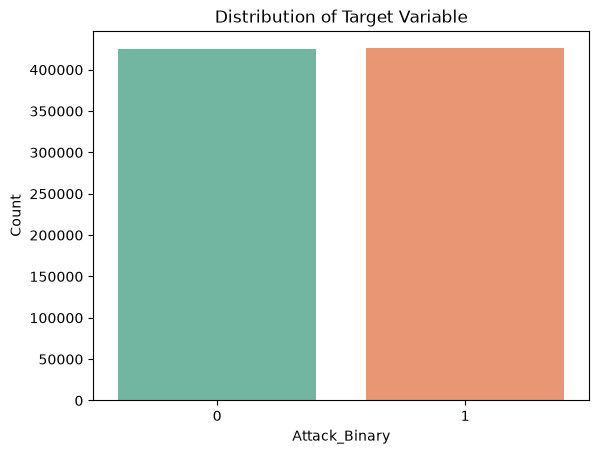

In [46]:
sns.countplot(x='Attack_Binary', data=df, palette='Set2')
plt.title("Distribution of Target Variable")
plt.xlabel("Attack_Binary")
plt.ylabel("Count")

plt.show()

Dataset is balanced means:
* The ANN will learn both classes equally.
* Accuracy will be a meaningful evaluation metric.

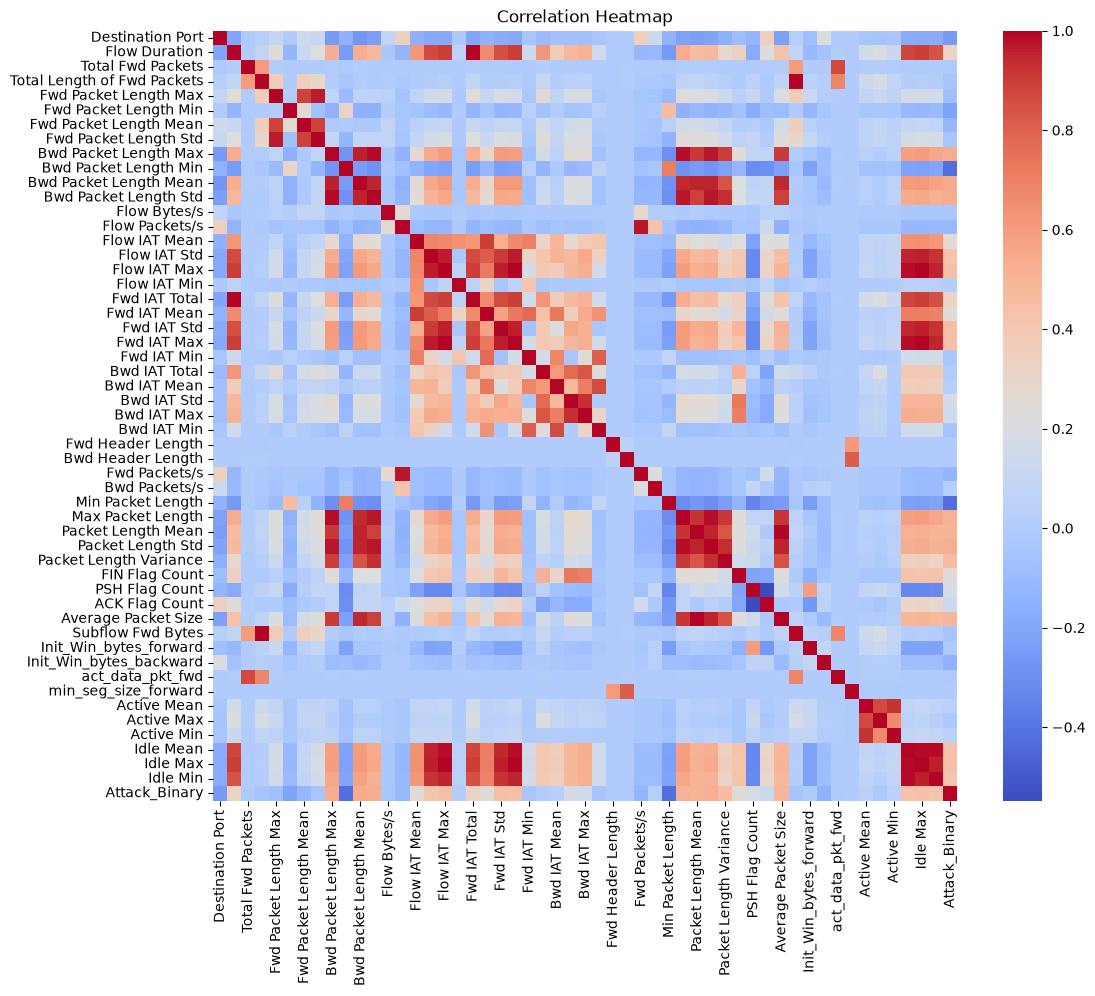

In [47]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [48]:
# Split the dataset into X and y
X = df.drop("Attack_Binary", axis=1)
y = df["Attack_Binary"]

In [49]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [50]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [51]:
model = Sequential([
    Dense(64, input_dim=52, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [52]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [53]:
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
17028/17028 ━━━━━━━━━━━━━━━━━━━━ 23s 1ms/step - accuracy: 0.9664 - loss: 0.0835 - val_accuracy: 0.9765 - val_loss: 0.0609
Epoch 2/5
17028/17028 ━━━━━━━━━━━━━━━━━━━━ 23s 1ms/step - accuracy: 0.9774 - loss: 0.0600 - val_accuracy: 0.9833 - val_loss: 0.0515
Epoch 3/5
17028/17028 ━━━━━━━━━━━━━━━━━━━━ 20s 1ms/step - accuracy: 0.9800 - loss: 0.0528 - val_accuracy: 0.9751 - val_loss: 0.0579
Epoch 4/5
17028/17028 ━━━━━━━━━━━━━━━━━━━━ 22s 1ms/step - accuracy: 0.9819 - loss: 0.0492 - val_accuracy: 0.9781 - val_loss: 0.0529
Epoch 5/5
17028/17028 ━━━━━━━━━━━━━━━━━━━━ 26s 2ms/step - accuracy: 0.9826 - loss: 0.0477 - val_accuracy: 0.9843 - val_loss: 0.0407


In [54]:
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

5322/5322 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.9841 - loss: 0.0414
Test Loss: 0.04136479273438454
Test Accuracy: 0.9841433763504028


In [55]:
y_pred = model.predict(X_test_scaled)

5322/5322 ━━━━━━━━━━━━━━━━━━━━ 4s 661us/step


In [56]:
y_pred = (y_pred > 0.5).astype(int)

In [57]:
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.97      0.98     85137
           1       0.97      1.00      0.98     85139

    accuracy                           0.98    170276
   macro avg       0.98      0.98      0.98    170276
weighted avg       0.98      0.98      0.98    170276

[[82754  2383]
 [  317 84822]]


Our model achieved 98.41% test accuracy. It correctly detected 84,822 attacks and missed only 317 attacks (false negatives). The model achieved 99.62% recall for attack detection, meaning it successfully identified the majority malicious network activities. It also incorrectly flagged 2,383 normal connections as attacks (false positives). In cybersecurity, minimizing false negatives is critical because missed attacks can lead to potential security breaches.

## Saving Model 

In [73]:
model.save("../models/network_intrusion_detection_ann.keras")

In [74]:
import joblib
joblib.dump(scaler, "../models/scaler.pkl")

['../models/scaler.pkl']

## Testing Trained Model 

In [75]:
from tensorflow.keras.models import load_model
import joblib

# Load model and scaler
model = load_model("../models/network_intrusion_detection_ann.keras")
scaler = joblib.load("../models/scaler.pkl")

# Take one sample
sample = X_test.iloc[[0]]

# Scale
sample_scaled = scaler.transform(sample)

# Predict
prediction = model.predict(sample_scaled)
prediction = (prediction > 0.5).astype(int)

# Display result
if prediction[0][0] == 1:
    print("🚨 Attack Detected")
else:
    print("✅ Normal Traffic")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
✅ Normal Traffic


In [76]:
print("Actual Value:", y_test.iloc[0])

Actual Value: 0
